In [8]:
import torch
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device: ", device)

device:  cuda


In [26]:
model_seg = YOLO("model/model_seg.pt")


image 1/1 c:\Users\1tram\OneDrive\Documents\KLTN-NAM\tmp\test-image\test2.jpg: 384x640 1 Lane, 59.1ms
Speed: 2.1ms preprocess, 59.1ms inference, 4.7ms postprocess per image at shape (1, 3, 384, 640)


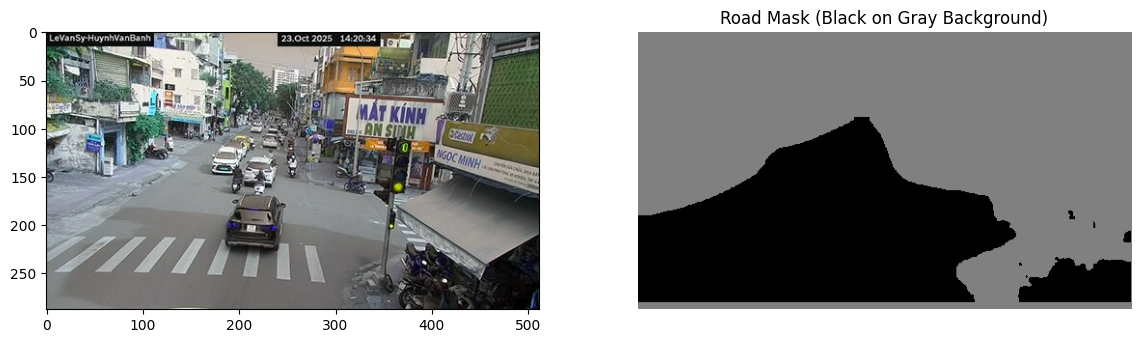

In [32]:
img_path = r"tmp\test-image\test2.jpg"

road = model_seg.predict(source=img_path,
                         device = device,
                         save = False,
                         show = True)

road_mask = road[0].masks.data.cpu().numpy()
road_mask = np.sum(road_mask, axis=0)
road_mask = (road_mask > 0.5).astype(np.uint8)

img = cv2.imread(img_path)
h, w, _ = img.shape

# resize
road_mask = cv2.resize(road_mask, (w, h), interpolation=cv2.INTER_NEAREST)

background = np.full((h, w, 3), 128, dtype=np.uint8)
background[road_mask == 1] = (0, 0, 0)

background_rgb = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.imshow(background_rgb)

plt.axis("off")
plt.title("Road Mask (Black on Gray Background)")
plt.show()
